In [2]:
import numpy as np
print(np.__version__)   # e.g. 2.4.2
import pandas as pd
print(pd.__version__) 


import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import roc_auc_score, f1_score, classification_report, confusion_matrix
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

import os 
# confirm the working directory and file existence
import os
print("cwd:", os.getcwd())
print("exists:", os.path.isfile("personal_finance_dataset.xlsx"))

# read the 'datathon_finance' sheet from the Excel file
df = pd.read_excel("personal_finance_dataset.xlsx", sheet_name="datathon_finance")

column_mapping = {
    'PAGEMIEG': 'Age_Group',
    'PATTCRU':  'Credit_Card_Payment_Behavior',
    'PATTSITC': 'COVID_Financial_Impact',
    'PATTSKP':  'Skipped_Payments',
    'PEDUCMIE': 'Education_Level',
    'PEFATINC': 'Annual_After_Tax_Income',
    'PFMTYPG':  'Family_Type',
    'PFTENUR':  'Home_Ownership',
    'PLFFPTME': 'Work_Status_2022',
    'PNBEARG':  'Number_of_Earners',
    'PPVRES':   'Province',
    'PWAPRVAL': 'Home_Value',
    'PWASTDEP': 'Bank_Deposits',
    'PWATFS':   'TFSA_Balance',
    'PWDPRMOR': 'Mortgage_Debt',
    'PWDSLOAN': 'Student_Loan_Debt',
    'PWDSTCRD': 'Credit_Card_Debt',
    'PWDSTLOC': 'Line_of_Credit_Debt',
    'PWNETWPG': 'Net_Worth'
}

df.rename(columns=column_mapping, inplace=True)

print(df.head())

2.4.2
3.0.1
cwd: /Users/haianhha/Documents/GitHub/JTAFinance
exists: True
   Age_Group  Credit_Card_Payment_Behavior  COVID_Financial_Impact  \
0          6                             4                       3   
1          7                             4                       3   
2          5                             4                       3   
3          6                             3                       3   
4          4                             4                       3   

   Skipped_Payments  Education_Level  Annual_After_Tax_Income  Family_Type  \
0                 2                4                   115525            4   
1                 2                9                   121300            2   
2                 2                4                    19175            2   
3                 2                4                   147425            2   
4                 2                3                    56750            1   

   Home_Ownership  Work_Status_2022 

In [3]:

def define_resilience(df, shock_percentage=0.15):
    """
    Add financial resilience metrics and at-risk flags to the dataset.
    shock_percentage = 0.15 means we simulate a +15% increase in yearly essential expenses.
    """
    df = df.copy()  # work on a copy so we don't overwrite the original

    # 1. Annual essential expenses & liquidity runway

    # Total liquid savings: cash that can be accessed quickly
    df["Total_Liquidity"] = df["Bank_Deposits"] + df["TFSA_Balance"]

    # Approximate essential annual expenses as 60% of after-tax income
    df["Annual_Expenses_Base"] = df["Annual_After_Tax_Income"] * 0.60

    # Years_of_Runway: how many YEARS these savings can cover essential expenses if income = 0
    df["Years_of_Runway"] = df["Total_Liquidity"] / df["Annual_Expenses_Base"].replace(0, np.nan)

    # -------------------------------
    # 2. Housing burden (share of income spent on housing)

    # Estimate annual housing cost based on tenure:
    # - Home_Ownership == 2 (owner with mortgage): ~4% of mortgage debt per year
    # - Home_Ownership == 3 (renter): ~30% of annual income as rent
    # - Otherwise (own outright or missing): assume 0 recurring housing cost
    df["Est_Annual_Housing_Cost"] = np.where(
        df["Home_Ownership"] == 2,
        df["Mortgage_Debt"] * 0.04,
        np.where(
            df["Home_Ownership"] == 3,
            df["Annual_After_Tax_Income"] * 0.30, 0.0
        ),
    )

    # Housing_Burden_Ratio: cost/ income
    df["Housing_Burden_Ratio"] = df["Est_Annual_Housing_Cost"] / df["Annual_After_Tax_Income"].replace(0, np.nan)

    # -------------------------------
    # 3. Consumer debt burden (non-mortgage DTI)

    # Total consumer debt = credit card + line of credit + student loans
    df["Total_Consumer_Debt"] = ( df["Credit_Card_Debt"] + df["Line_of_Credit_Debt"] + df["Student_Loan_Debt"] )

    # DTI_Ratio: consumer debt relative to annual after-tax income
    df["DTI_Ratio"] = df["Total_Consumer_Debt"] / df["Annual_After_Tax_Income"].replace(0, np.nan)

    # -------------------------------    
    # 4. Baseline "At Risk" label (no shock)

    # If the dataset has a Skipped_Payments indicator, use it; otherwise treat as all False
    has_skipped_col = "Skipped_Payments" in df.columns
    skipped_flag = (df["Skipped_Payments"] == 1) if has_skipped_col else False

    # Define baseline at-risk:
    # - Runway < 0.25 years (~3 months), OR
    # - Housing burden > 35% of income, OR
    # - Consumer DTI > 50% of income, OR
    # - Skipped payments in last year
    df["Is_At_Risk_Base"] = np.where(
        (df["Years_of_Runway"] < 0.25)|
        (df["Housing_Burden_Ratio"] > 0.35)|
        (df["DTI_Ratio"] > 0.50)|
        skipped_flag,
        1,
        0,
    )

    # -------------------------------
    # 5. Economic shock: expenses + shock_percentage (e.g., +15%)

    # Inflate essential expenses by the shock factor (e.g., 1.15 for +15%)
    df["Annual_Expenses_Shocked"] = df["Annual_Expenses_Base"] * (1 + shock_percentage)

    # Recompute runway under higher expenses
    df["Runway_Post_Shock"] = df["Total_Liquidity"] / df["Annual_Expenses_Shocked"].replace(0, np.nan)

    # At risk under shock: runway after shock < 0.25 years (~3 months)
    df["Is_At_Risk_Shocked"] = np.where(df["Runway_Post_Shock"] < 0.25, 1, 0)

    # Became_Vulnerable: people who were safe at baseline but become at risk after the shock
    df["Became_Vulnerable"] = ((df["Is_At_Risk_Base"] == 0) & (df["Is_At_Risk_Shocked"] == 1)).astype(int)

    return df

# Apply the function to your current df (15% shock by default)
df = define_resilience(df, shock_percentage=0.15)

# Quick check: how many are at risk before vs after the shock?
print("Baseline at-risk rate: ", df["Is_At_Risk_Base"].mean())
print("Post-shock at-risk rate:", df["Is_At_Risk_Shocked"].mean())
print("Became vulnerable share:", df["Became_Vulnerable"].mean())

Baseline at-risk rate:  0.4308847977341297
Post-shock at-risk rate: 0.3898158980358352
Became vulnerable share: 0.01834862385321101


In [5]:
# What correlates most with being 'At Risk'?
correlations = df[['Is_At_Risk_Base', 'Annual_After_Tax_Income', 'Total_Liquidity', 
                  'Housing_Burden_Ratio', 'Student_Loan_Debt', 'Credit_Card_Debt']].corr()['Is_At_Risk_Base'].sort_values()

print("Top Risk Drivers (Correlation):")
print(correlations)

Top Risk Drivers (Correlation):
Total_Liquidity           -0.330574
Annual_After_Tax_Income   -0.058806
Housing_Burden_Ratio       0.025991
Student_Loan_Debt          0.137175
Credit_Card_Debt           0.267851
Is_At_Risk_Base            1.000000
Name: Is_At_Risk_Base, dtype: float64


In [6]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import roc_auc_score, f1_score, classification_report, confusion_matrix
from sklearn.ensemble import RandomForestClassifier

target = "Is_At_Risk_Base"
y = df[target]

features = [
    "Age_Group","Education_Level","Home_Ownership","Work_Status_2022","Province",
    "Annual_After_Tax_Income","Total_Liquidity","Housing_Burden_Ratio",
    "Student_Loan_Debt","Credit_Card_Debt","DTI_Ratio"
]
X = df[features]

cat_cols = ["Age_Group","Education_Level","Home_Ownership","Work_Status_2022","Province"]
num_cols = [c for c in features if c not in cat_cols]

preprocess = ColumnTransformer([
    ("num", Pipeline([("imputer", SimpleImputer(strategy="median"))]), num_cols),
    ("cat", Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]), cat_cols),
])

rf = RandomForestClassifier(
    n_estimators=500,
    random_state=42,
    class_weight="balanced_subsample"
)

clf = Pipeline([("prep", preprocess), ("model", rf)])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

clf.fit(X_train, y_train)

proba = clf.predict_proba(X_test)[:, 1]
pred = (proba >= 0.5).astype(int)

print("ROC-AUC:", roc_auc_score(y_test, proba))
print("F1:", f1_score(y_test, pred))
print(classification_report(y_test, pred))
print("Confusion matrix:\n", confusion_matrix(y_test, pred))

ROC-AUC: 0.9844382765654943
F1: 0.9497109826589596
              precision    recall  f1-score   support

           0       0.95      0.97      0.96      2311
           1       0.96      0.94      0.95      1750

    accuracy                           0.96      4061
   macro avg       0.96      0.95      0.96      4061
weighted avg       0.96      0.96      0.96      4061

Confusion matrix:
 [[2244   67]
 [ 107 1643]]


clf exists: True
X_test exists: True
y_test exists: True


/var/folders/12/9c7n0p_101z2n53fw4xvcqfw0000gn/T/ipykernel_72806/3598850891.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top, x="importance", y="feature", palette="viridis")  # same vibe as your RF plot


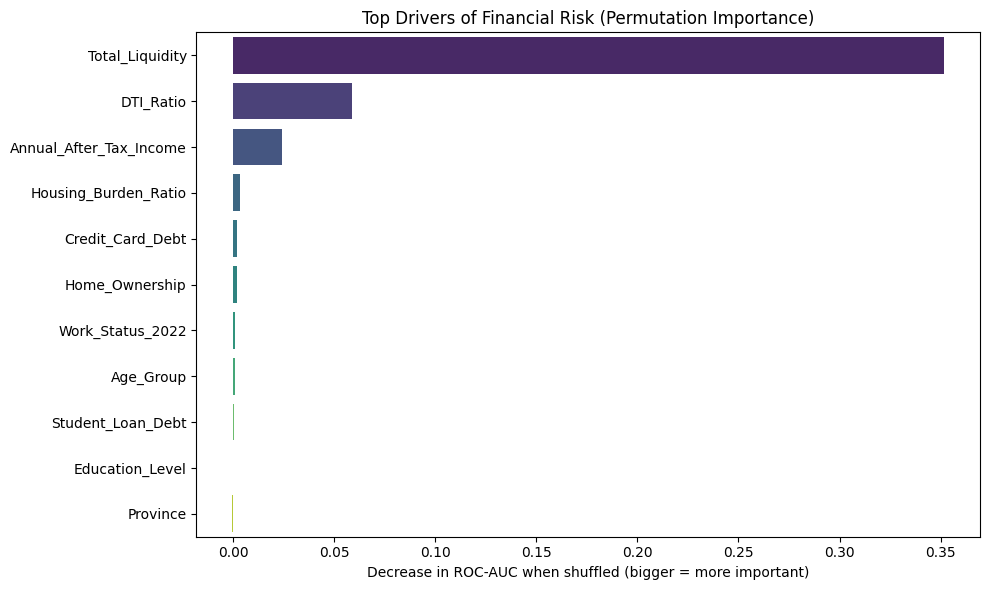

,feature,importance
0,Total_Liquidity,0.351871
1,DTI_Ratio,0.058800
2,Annual_After_Tax_Income,0.024133
3,Housing_Burden_Ratio,0.003184
4,Credit_Card_Debt,0.001971
5,Home_Ownership,0.001768
6,Work_Status_2022,0.001077
7,Age_Group,0.000730
8,Student_Loan_Debt,0.000321
9,Education_Level,0.000100


In [7]:
from sklearn.inspection import permutation_importance
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# sanity check (optional)
print("clf exists:", "clf" in globals())
print("X_test exists:", "X_test" in globals())
print("y_test exists:", "y_test" in globals())

r = permutation_importance(
    clf, X_test, y_test,
    n_repeats=8,
    random_state=42,
    scoring="roc_auc"
)

imp = pd.Series(r.importances_mean, index=X_test.columns).sort_values(ascending=False)

top = imp.head(15).reset_index()
top.columns = ["feature","importance"]

plt.figure(figsize=(10,6))
sns.barplot(data=top, x="importance", y="feature", palette="viridis")  # same vibe as your RF plot
plt.title("Top Drivers of Financial Risk (Permutation Importance)")
plt.xlabel("Decrease in ROC-AUC when shuffled (bigger = more important)")
plt.ylabel("")
plt.tight_layout()
plt.show()

top

In [8]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

persona_feats = ['Years_of_Runway', 'Housing_Burden_Ratio', 'DTI_Ratio',
                 'Student_Loan_Debt', 'Credit_Card_Debt', 'Total_Liquidity', 'Annual_After_Tax_Income']

P = df[persona_feats].replace([np.inf, -np.inf], np.nan).fillna(0)
P_scaled = StandardScaler().fit_transform(P)

k = 5
kmeans = KMeans(n_clusters=k, random_state=42, n_init=20)
df['persona'] = kmeans.fit_predict(P_scaled)

persona_summary = df.groupby('persona')[persona_feats + ['Is_At_Risk_Base']].mean()
persona_summary['risk_%'] = df.groupby('persona')['Is_At_Risk_Base'].mean() * 100
persona_summary.sort_values('risk_%', ascending=False)

,Years_of_Runway,Housing_Burden_Ratio,DTI_Ratio,Student_Loan_Debt,Credit_Card_Debt,Total_Liquidity,Annual_After_Tax_Income,Is_At_Risk_Base,risk_%
persona,,,,,,,,,
3,140.000000,0.300000,800.000000,0.000000,20000.000000,2100.000000,25.000000,1.000000,100.000000
4,1300.000000,280.000000,121.000000,0.000000,50.000000,39000.000000,50.000000,1.000000,100.000000
1,0.559190,0.141932,0.935392,15242.015926,24387.866723,30868.985750,114249.811400,0.835708,83.570830
0,1.520838,0.104286,0.162311,455.185457,1403.348380,69134.672825,95742.966618,0.415914,41.591434
2,15.686426,0.056190,0.341633,380.350066,706.737120,723764.299868,231262.945839,0.073976,7.397622


In [9]:
def shock_income_drop(df0, pct=0.10):
    temp = df0.copy()
    temp['Annual_After_Tax_Income'] = temp['Annual_After_Tax_Income'] * (1 - pct)
    return define_resilience(temp, shock_percentage=0.0)

def shock_mortgage_stress(df0, pct=0.15):
    temp = df0.copy()
    temp['Mortgage_Debt'] = temp['Mortgage_Debt'] * (1 + pct)
    return define_resilience(temp, shock_percentage=0.0)

base = define_resilience(df.copy(), shock_percentage=0.0)
income10 = shock_income_drop(df.copy(), 0.10)
mort15 = shock_mortgage_stress(df.copy(), 0.15)

pd.DataFrame({
    "scenario": ["Baseline", "Income -10%", "Mortgage debt +15%"],
    "at_risk_%": [base['Is_At_Risk_Base'].mean()*100,
                 income10['Is_At_Risk_Base'].mean()*100,
                 mort15['Is_At_Risk_Base'].mean()*100]
})

,scenario,at_risk_%
0,Baseline,43.088480
1,Income -10%,42.220307
2,Mortgage debt +15%,43.186996


In [10]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import roc_auc_score, f1_score, classification_report, confusion_matrix
from sklearn.ensemble import RandomForestClassifier

target = "Is_At_Risk_Base"
y = df[target]

features = [
    "Age_Group","Education_Level","Home_Ownership","Work_Status_2022","Province",
    "Annual_After_Tax_Income","Total_Liquidity","Housing_Burden_Ratio",
    "Student_Loan_Debt","Credit_Card_Debt","DTI_Ratio"
]
X = df[features]

cat_cols = ["Age_Group","Education_Level","Home_Ownership","Work_Status_2022","Province"]
num_cols = [c for c in features if c not in cat_cols]

preprocess = ColumnTransformer([
    ("num", Pipeline([("imputer", SimpleImputer(strategy="median"))]), num_cols),
    ("cat", Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]), cat_cols),
])

rf = RandomForestClassifier(
    n_estimators=500,
    random_state=42,
    class_weight="balanced_subsample"
)

clf = Pipeline([("prep", preprocess), ("model", rf)])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

clf.fit(X_train, y_train)

proba = clf.predict_proba(X_test)[:, 1]
pred = (proba >= 0.5).astype(int)

print("ROC-AUC:", roc_auc_score(y_test, proba))
print("F1:", f1_score(y_test, pred))
print(classification_report(y_test, pred))
print("Confusion matrix:\n", confusion_matrix(y_test, pred))

ROC-AUC: 0.9844382765654943
F1: 0.9497109826589596
              precision    recall  f1-score   support

           0       0.95      0.97      0.96      2311
           1       0.96      0.94      0.95      1750

    accuracy                           0.96      4061
   macro avg       0.96      0.95      0.96      4061
weighted avg       0.96      0.96      0.96      4061

Confusion matrix:
 [[2244   67]
 [ 107 1643]]


clf exists: True
X_test exists: True
y_test exists: True


/var/folders/12/9c7n0p_101z2n53fw4xvcqfw0000gn/T/ipykernel_72806/3598850891.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top, x="importance", y="feature", palette="viridis")  # same vibe as your RF plot


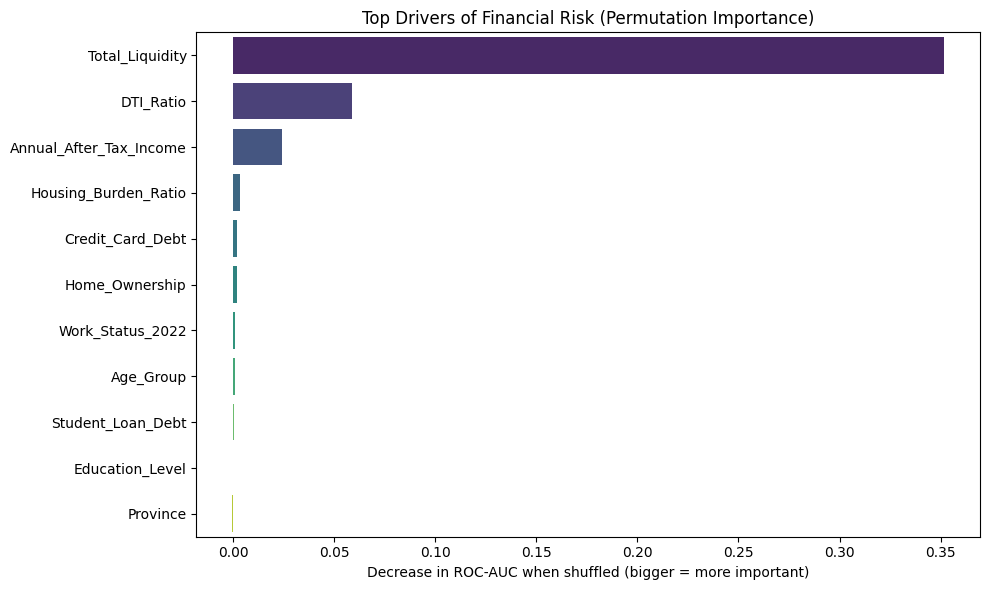

,feature,importance
0,Total_Liquidity,0.351871
1,DTI_Ratio,0.058800
2,Annual_After_Tax_Income,0.024133
3,Housing_Burden_Ratio,0.003184
4,Credit_Card_Debt,0.001971
5,Home_Ownership,0.001768
6,Work_Status_2022,0.001077
7,Age_Group,0.000730
8,Student_Loan_Debt,0.000321
9,Education_Level,0.000100


In [11]:
from sklearn.inspection import permutation_importance
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# sanity check (optional)
print("clf exists:", "clf" in globals())
print("X_test exists:", "X_test" in globals())
print("y_test exists:", "y_test" in globals())

r = permutation_importance(
    clf, X_test, y_test,
    n_repeats=8,
    random_state=42,
    scoring="roc_auc"
)

imp = pd.Series(r.importances_mean, index=X_test.columns).sort_values(ascending=False)

top = imp.head(15).reset_index()
top.columns = ["feature","importance"]

plt.figure(figsize=(10,6))
sns.barplot(data=top, x="importance", y="feature", palette="viridis")  # same vibe as your RF plot
plt.title("Top Drivers of Financial Risk (Permutation Importance)")
plt.xlabel("Decrease in ROC-AUC when shuffled (bigger = more important)")
plt.ylabel("")
plt.tight_layout()
plt.show()

top

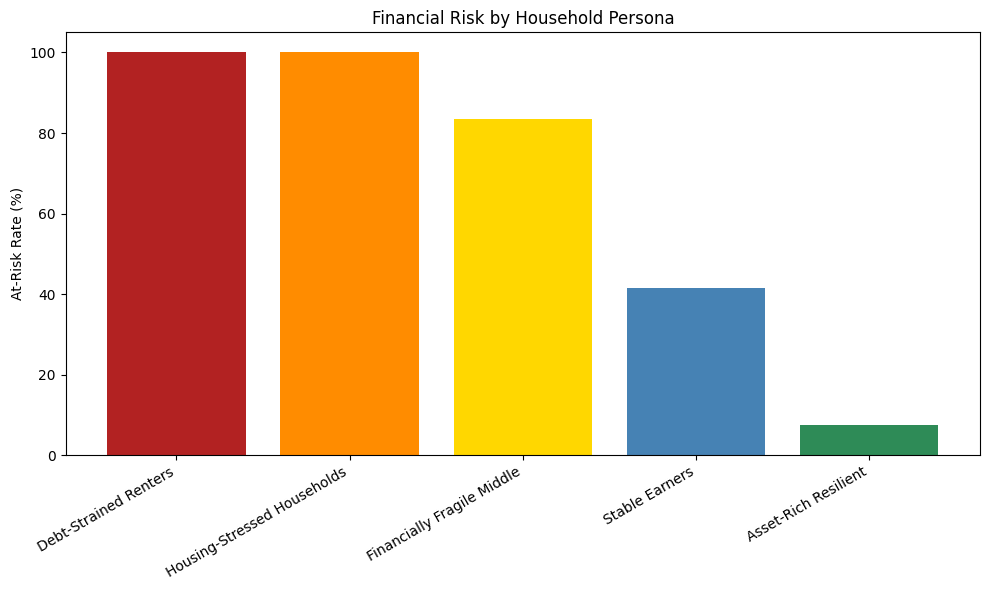

In [12]:
persona_colors = {
    0: "#B22222",   # dark red
    1: "#FF8C00",   # orange
    2: "#FFD700",   # gold
    3: "#4682B4",   # steel blue
    4: "#2E8B57"    # sea green
}

# First assign names based on sorted order
persona_summary = persona_summary.sort_values("risk_%", ascending=False).reset_index()

persona_names = [
    "Debt-Strained Renters",
    "Housing-Stressed Households",
    "Financially Fragile Middle",
    "Stable Earners",
    "Asset-Rich Resilient"
]

persona_summary["Persona_Name"] = persona_names[:len(persona_summary)]

# Define colors from high risk to low risk
colors = ["#B22222", "#FF8C00", "#FFD700", "#4682B4", "#2E8B57"]

plt.figure(figsize=(10,6))
plt.bar(persona_summary["Persona_Name"], persona_summary["risk_%"], color=colors[:len(persona_summary)])
plt.xticks(rotation=30, ha="right")
plt.ylabel("At-Risk Rate (%)")
plt.title("Financial Risk by Household Persona")
plt.tight_layout()
plt.show()

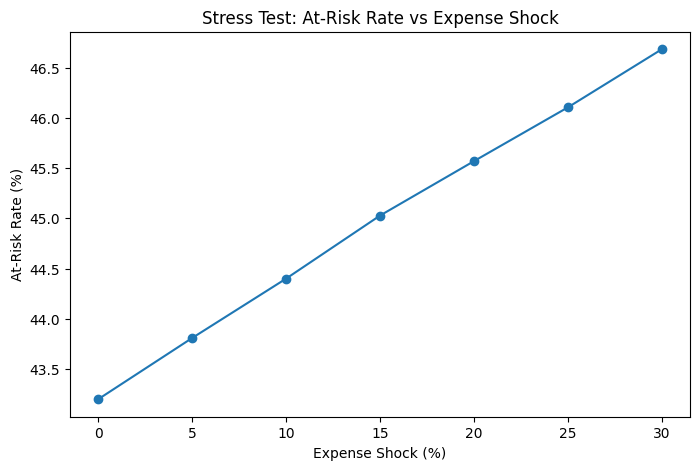

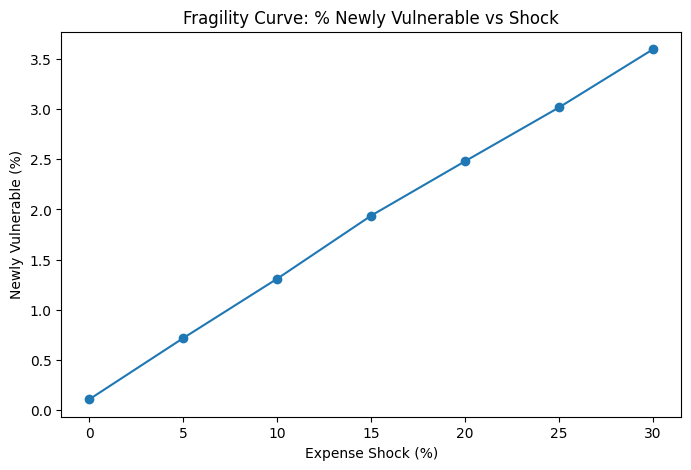

In [13]:

def stress_test_curve(df, shock_grid=np.arange(0, 0.31, 0.05)):
    df = df.copy()

    # --- ensure required columns exist ---
    required = ["Total_Liquidity", "Annual_Expenses_Base", "Annual_After_Tax_Income",
                "Housing_Burden_Ratio", "DTI_Ratio", "Skipped_Payments"]
    missing = [c for c in required if c not in df.columns]
    if missing:
        raise KeyError(f"Missing columns needed for stress test: {missing}")

    rates = []
    newly_vuln = []

    for s in shock_grid:
        temp = df.copy()

        # shocked expenses
        temp["Annual_Expenses_Shocked"] = temp["Annual_Expenses_Base"] * (1 + s)

        # runway in YEARS under shock
        temp["Runway_Post_Shock"] = temp["Total_Liquidity"] / temp["Annual_Expenses_Shocked"].replace(0, np.nan)

        # define shocked risk using SAME baseline logic style
        temp["Is_At_Risk_Shocked"] = np.where(
            (temp["Runway_Post_Shock"] < 0.25) |              # <3 months
            (temp["Housing_Burden_Ratio"] > 0.30) |
            (temp["DTI_Ratio"] > 0.50) |
            (temp["Skipped_Payments"] == 1),
            1, 0
        )

        # if baseline doesn't exist, compute a baseline version too
        if "Is_At_Risk_Base" not in temp.columns:
            temp["Is_At_Risk_Base"] = np.where(
                ((temp["Total_Liquidity"] / temp["Annual_Expenses_Base"].replace(0, np.nan)) < 0.25) |
                (temp["Housing_Burden_Ratio"] > 0.30) |
                (temp["DTI_Ratio"] > 0.50) |
                (temp["Skipped_Payments"] == 1),
                1, 0
            )

        temp["Became_Vulnerable"] = ((temp["Is_At_Risk_Base"] == 0) & (temp["Is_At_Risk_Shocked"] == 1)).astype(int)

        rates.append(temp["Is_At_Risk_Shocked"].mean() * 100)
        newly_vuln.append(temp["Became_Vulnerable"].mean() * 100)

    return shock_grid, rates, newly_vuln


shock_grid = np.arange(0, 0.31, 0.05)
shock_grid, rates, newly_vuln = stress_test_curve(df, shock_grid)

plt.figure(figsize=(8,5))
plt.plot(shock_grid*100, rates, marker="o")
plt.xlabel("Expense Shock (%)")
plt.ylabel("At-Risk Rate (%)")
plt.title("Stress Test: At-Risk Rate vs Expense Shock")
plt.show()

plt.figure(figsize=(8,5))
plt.plot(shock_grid*100, newly_vuln, marker="o")
plt.xlabel("Expense Shock (%)")
plt.ylabel("Newly Vulnerable (%)")
plt.title("Fragility Curve: % Newly Vulnerable vs Shock")
plt.show()

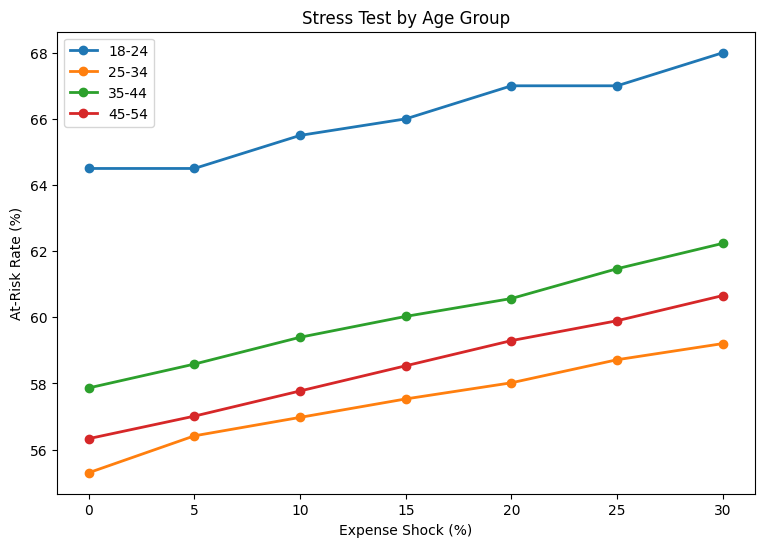

In [14]:
age_labels = {1:"18-24", 2:"25-34", 3:"35-44", 4:"45-54"}

plt.figure(figsize=(9,6))
for ag in sorted(age_labels.keys()):
    if ag in df["Age_Group"].unique():
        sub = df[df["Age_Group"] == ag]
        _, r, _ = stress_test_curve(sub, shock_grid)
        plt.plot(shock_grid*100, r, marker="o", label=age_labels[ag], linewidth=2)

plt.xlabel("Expense Shock (%)")
plt.ylabel("At-Risk Rate (%)")
plt.title("Stress Test by Age Group")
plt.legend()
plt.show()